# Machine Learning

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

### Loading The Dataset

In [32]:
from sklearn.datasets import fetch_california_housing
california_bunch = fetch_california_housing(as_frame=True)
df = california_bunch.frame
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Exploring The Dataset

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [34]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [35]:
df.sum()

MedInc         7.989065e+04
HouseAge       5.911190e+05
AveRooms       1.120546e+05
AveBedrms      2.263538e+04
Population     2.942184e+07
AveOccup       6.337832e+04
Latitude       7.354416e+05
Longitude     -2.467919e+06
MedHouseVal    4.269504e+04
dtype: float64

In [36]:
df.isna()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
20635,False,False,False,False,False,False,False,False,False
20636,False,False,False,False,False,False,False,False,False
20637,False,False,False,False,False,False,False,False,False
20638,False,False,False,False,False,False,False,False,False


In [37]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Here There is no missing values

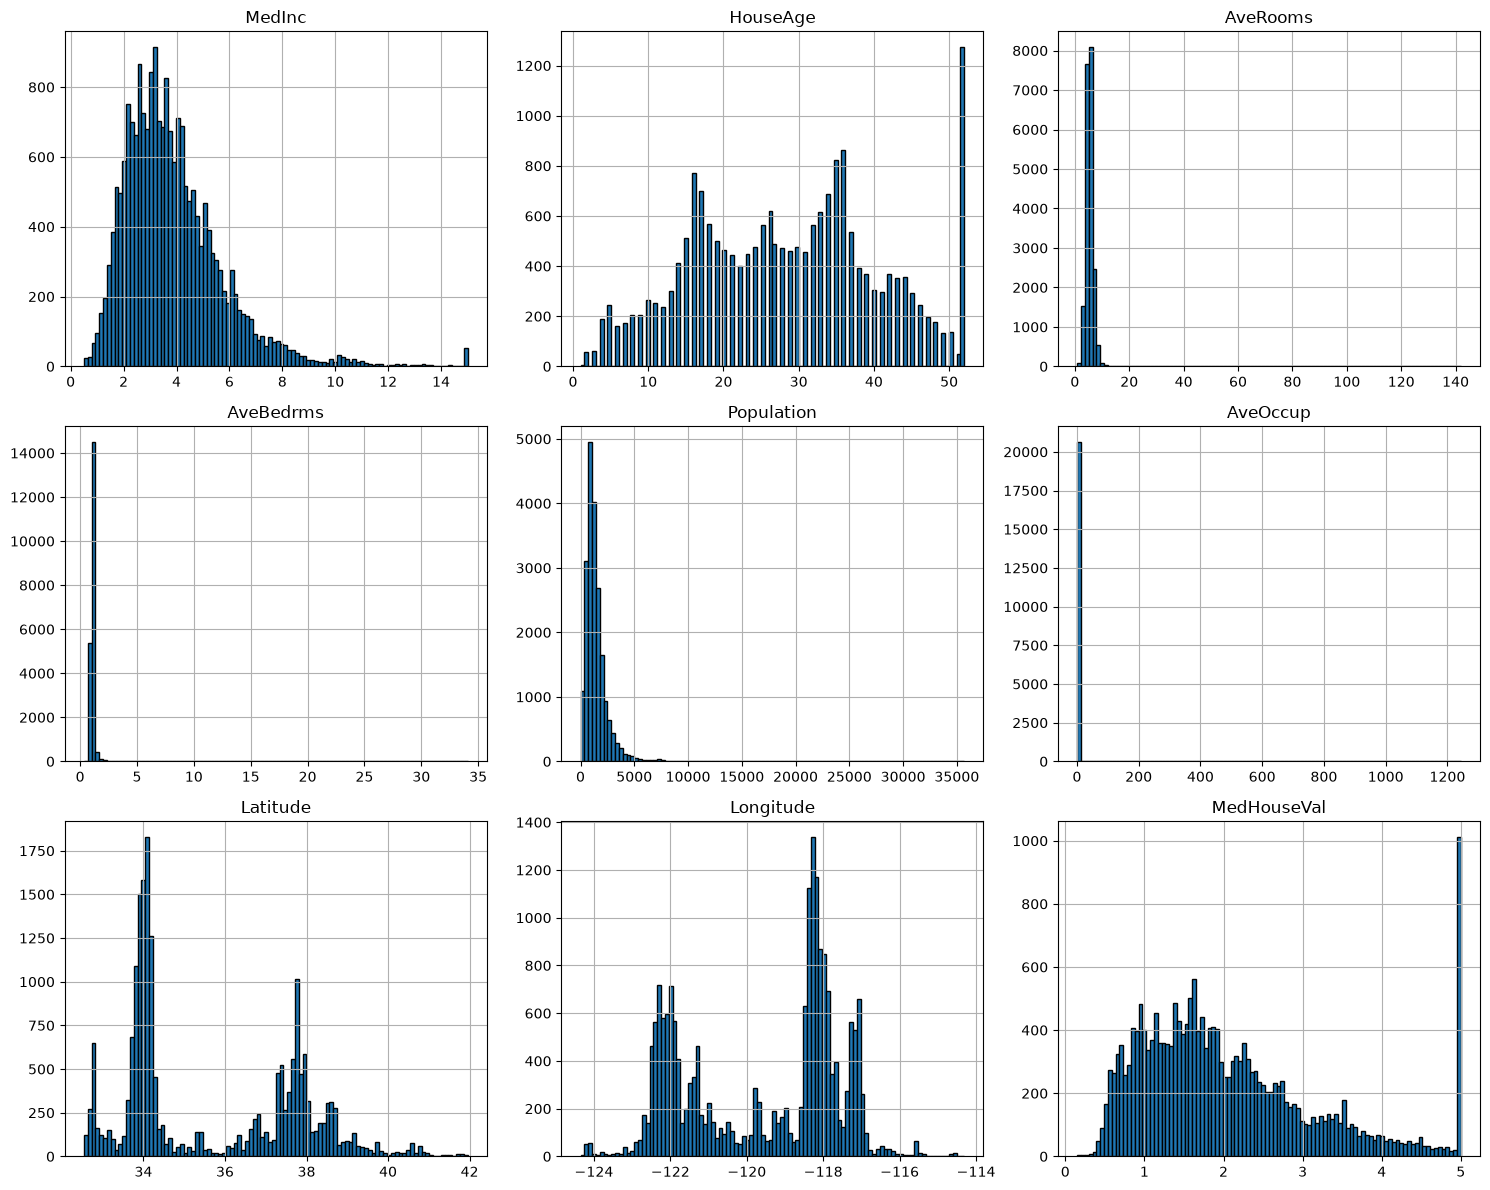

In [38]:
df.hist(bins=100,edgecolor='black',figsize=(15,12))
plt.tight_layout()
plt.show()

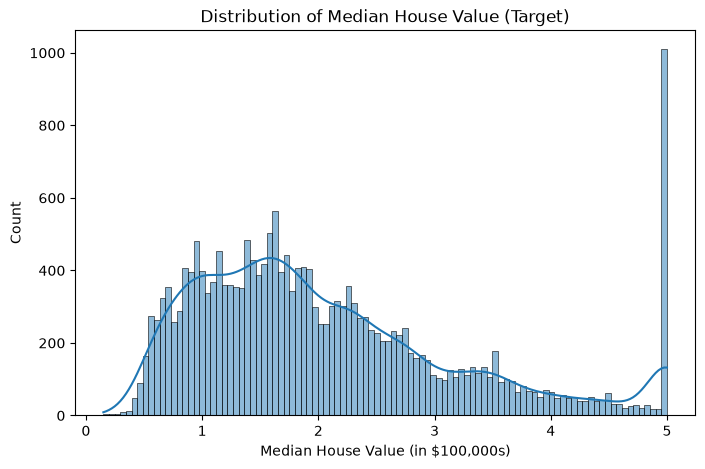

In [39]:
# Plot only the target distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='MedHouseVal', bins=100, edgecolor='black', kde=True)

plt.title('Distribution of Median House Value (Target)')
plt.xlabel('Median House Value (in $100,000s)')
plt.ylabel('Count')
plt.show()


When the survey is done the highest value there is 5,00,000 dollars or more so any house greater than this price automatically falls down to this last box so this last box collects a lot of datas that is 5,00,000 or more

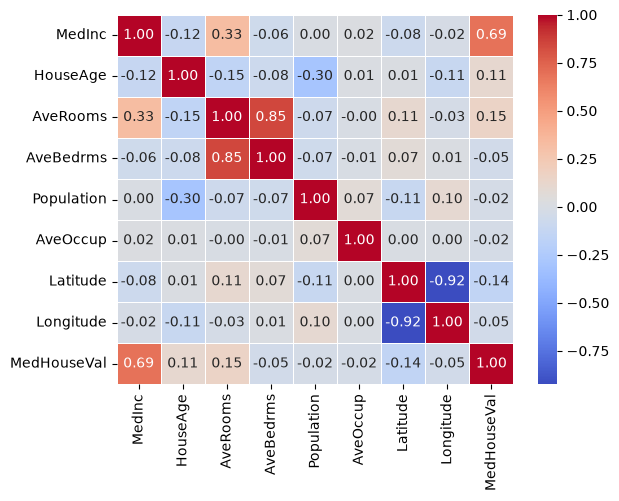

In [40]:
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt=".2f",linewidths=0.5)
plt.show()

The top 3 features related with target is MedHouseval-0.69 and Averooms-0.15, latitude=-0.14

and the top correlated features is Avebedrms-Averooms(0.85) and Latitude-longitude(-0.92)

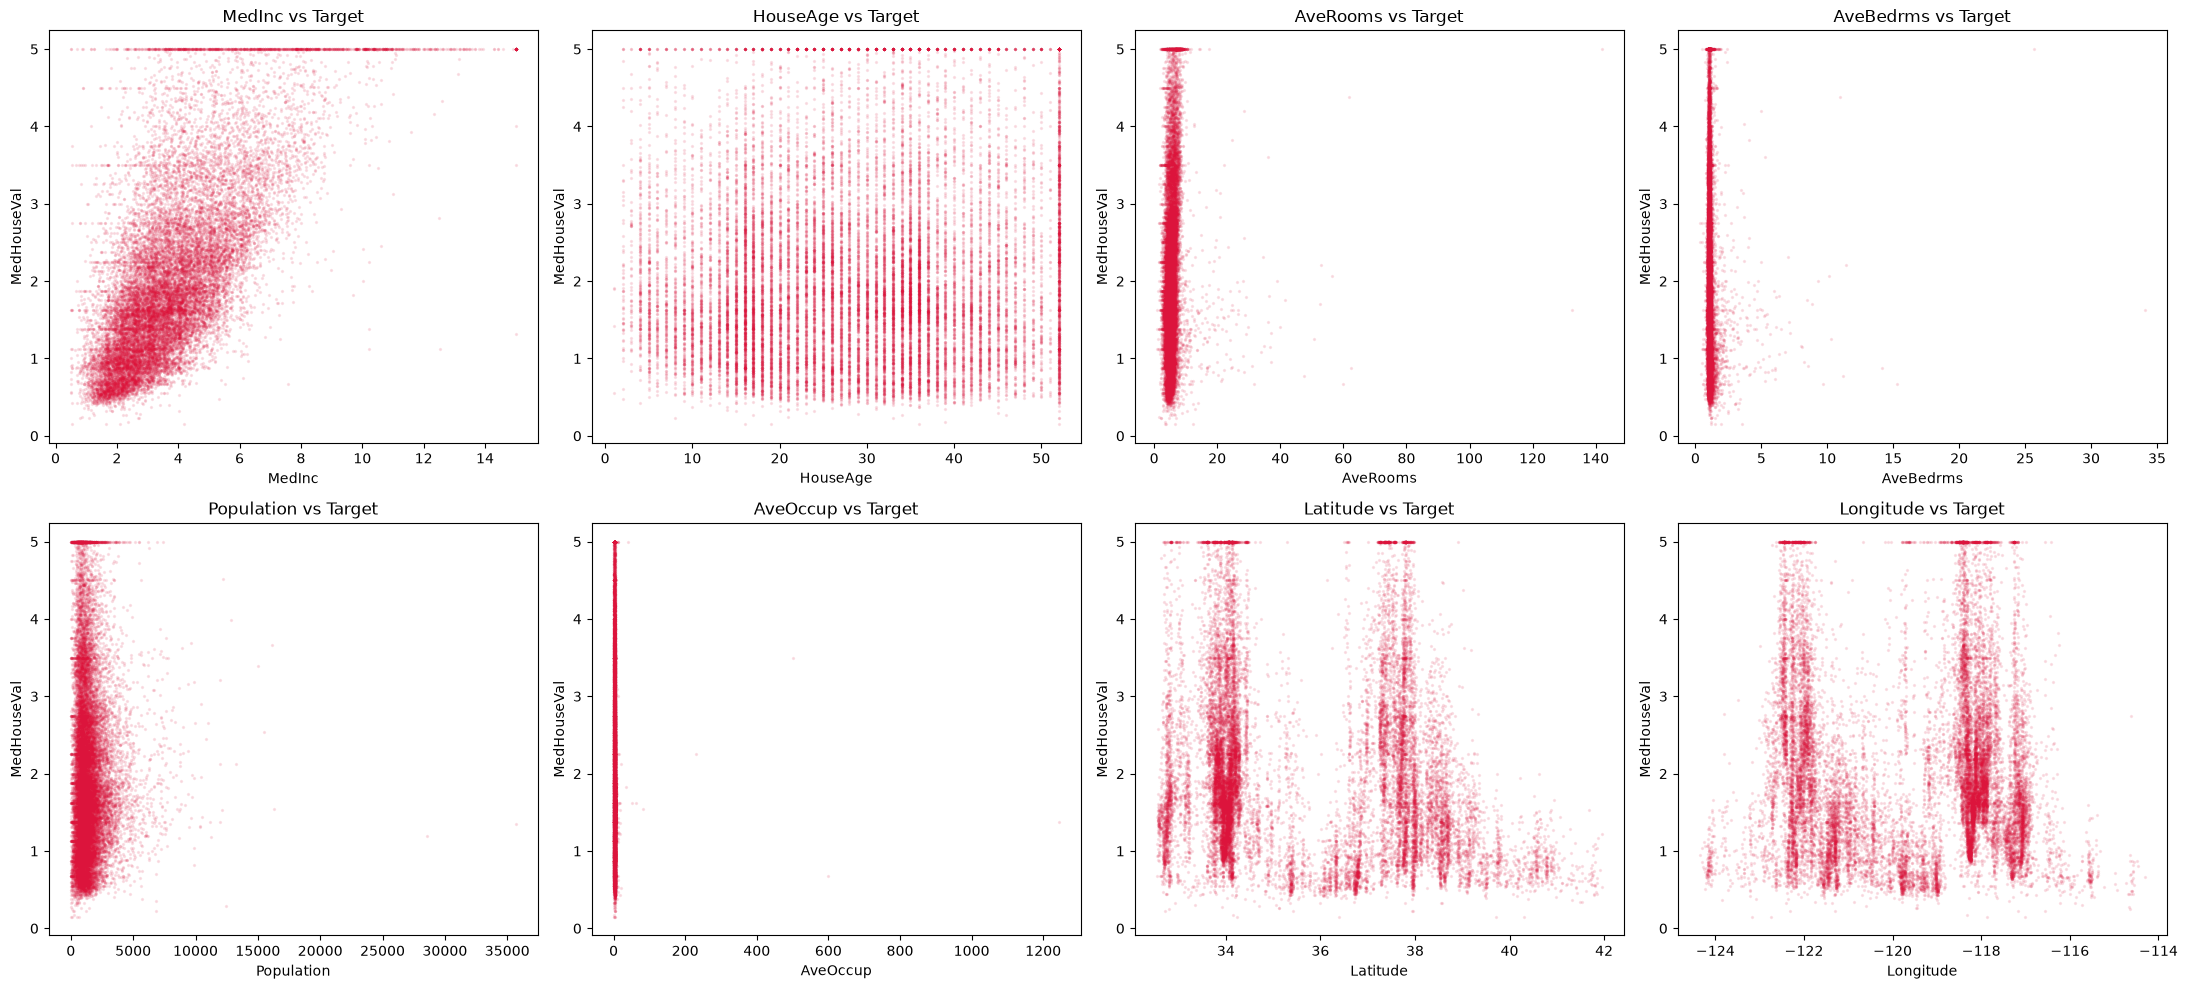

In [41]:
# 1. Separate features from the target
features = [col for col in df.columns if col != 'MedHouseVal']

# 2. Create the 2x4 layout grid
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(22, 10))
axes = axes.flatten()  # Flattens the grid into a single list of 8 slots

# 3. Loop through and plot each feature
for i, feature in enumerate(features):
    # alpha=0.1 helps see through dense clusters of points
    axes[i].scatter(df[feature], df['MedHouseVal'], alpha=0.1, s=2, color='crimson')
    axes[i].set_title(f'{feature} vs Target')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('MedHouseVal')

plt.tight_layout()
plt.show()


### Boxplot For Checking Outliers

Text(0.5, 1.0, 'Comaprison Of Selected Features')

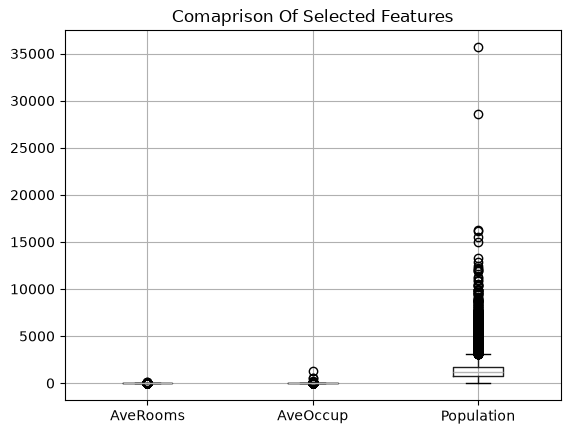

In [42]:
df[['AveRooms','AveOccup','Population']].boxplot()
plt.title('Comaprison Of Selected Features')

Population Has Outliers


1. Data Leakage and the Preprocessing Split

Data leakage occurs when information from outside the training dataset is accidentally used to train the machine learning model. This creates an overly optimistic illusion of high performance during training and validation, but causes the model to perform poorly on entirely new, unseen data.

Why You Must Split Before Scaling

When you scale your data (for example, using StandardScaler or MinMaxScaler), the mathematical transformation relies on calculating global parameters:
• StandardScaler requires the Mean (\(\mu \)) and Standard Deviation (\(\sigma \)).
• MinMaxScaler requires the Minimum and Maximum values.
If you apply a scaler to your entire dataset before performing a train-test split, the scaler calculates these parameters using data points from both sets. Consequently, the training set inherits information about the exact distribution, range, and variance of the test set. When the model trains on this scaled data, it has already "peeked" at the test set parameters.
To prevent this, you must split first, fit the scaler only on the training data (scaler.fit(X_train)), and then transform both sets (scaler.transform(X_train) and scaler.transform(X_test)).

2. High Correlation (\(\sim \)0.9) vs. Model Quality

No, a 0.9 correlation does not guarantee a good model. While a strong linear relationship makes prediction significantly easier, it does not account for several systemic issues:
• Non-Linear Complexity: Pearson correlation strictly measures linear relationships. If the remaining variance or underlying mechanics of the system are highly non-linear or multi-modal, a basic linear model will still yield poor predictions.
• Data Leakage or Target Snooping: A feature might have a 0.9 correlation simply because it is a proxy for the target itself. For example, predicting if a customer will churn using a feature like Closed_Account_Date will yield a near-perfect correlation, but the feature is completely useless for predicting future churn ahead of time.
• Capping and Outliers: A single extreme cluster of outliers or a censored/capped dataset boundary can artificially skew a correlation coefficient high, while the model fails completely to predict values across normal operational ranges.
• Overfitting on Noise: High correlation in a small dataset could be pure statistical coincidence, causing the model to overfit to noise rather than learning generalisable patterns.

3. Impact of a Capped Target Near the Cap

A capped target variable creates a structural dead-zone that breaks the core mathematical assumptions of linear regression:
• Artificial Error Penalization: If a home's actual structural value is $800,000, but the dataset forces its target value to $500,000, a logical linear model might predict something close to its true value (e.g., $750,000). The loss function sees this accurate prediction as a massive error (\(\$750k - \$500k = \$250k\) residual penalty) and forces the regression line downward to fit the artificial cap.
• Flattened Slopes (Underprediction): Because the model is heavily penalized for crossing the threshold, the feature weights (slopes) become artificially flattened. Near the capping boundary, the model will consistently underpredict the values of high-end assets.
• Non-Normal Residual Distribution: Linear regression assumes that errors are random and normally distributed around zero. A capped target introduces a hard, artificial ceiling. Right at the cap, the errors become completely non-random and strictly one-sided, destabilizing the model's capacity to minimize variance effectively.

Simple Linear Regression

In [43]:
class SimpleRegression:
    def __init__(self):
       self.m=None
       self.b=None
    
    def fit(self,x_train,y_train):
        size=len(x_train)
        num=0
        denom=0
        for i in range(0,size):
            num+=(x_train[i]-x_train.mean())*(y_train[i]-y_train.mean())
            denom+=(x_train[i]-x_train.mean())*(x_train[i]-x_train.mean())
        self.m=num/denom
        self.b=(y_train.mean()-self.m*x_train.mean())
        print("slope is",self.m)
        print("Intercept is",self.b)
    
    def predict(self,x_test):
        return self.m*x_test+self.b

In [44]:
from sklearn.model_selection import train_test_split
x=df['MedInc']
y=df['MedHouseVal']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
train=SimpleRegression()

# we cant directly put the x train ,y_train because their index is not 1,2,3 the pandas dataframe separated values can be randomly selected 80% index like 5,1,67,89,34,like these
# so we are first converting it into the numpy
x_train = x_train.to_numpy()
y_train = y_train.to_numpy()
x_test = x_test.to_numpy()
y_test = y_test.to_numpy()
train.fit(x_train,y_train)

slope is 0.41973808847515015
Intercept is 0.44318624770078907


In [52]:
train.predict(x_test)

array([3.13429503, 2.19949633, 1.17399223, ..., 1.35582277, 1.11573259,
       2.21561427], shape=(4128,))

Matching from the actual one

In [53]:
from sklearn.linear_model import LinearRegression

Lr = LinearRegression()

Lr.fit(x_train.reshape(-1, 1), y_train)
y_pred=Lr.predict(x_test.reshape(-1,1))
print(y_pred)

[3.13429503 2.19949633 1.17399223 ... 1.35582277 1.11573259 2.21561427]


In [58]:
new_data = np.array([[2], [5], [8]])
train.predict(new_data)

array([[1.28266242],
       [2.54187669],
       [3.80109096]])

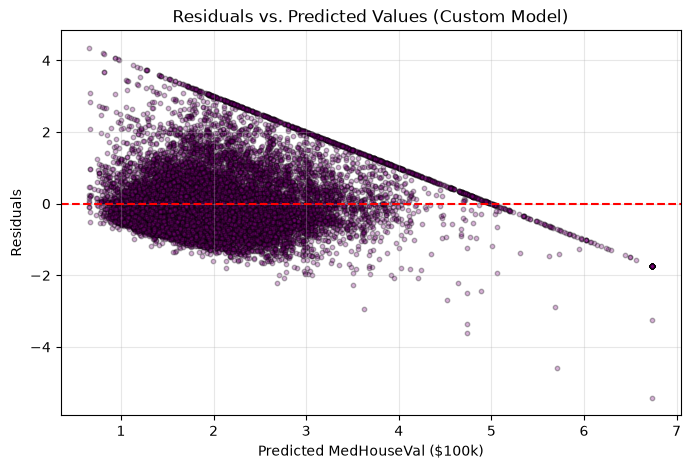

In [64]:
import matplotlib.pyplot as plt

# 1. Predict using your custom scratch model on the training data
# (Ensure x_train is a NumPy array as you handled in your code)
y_pred_train = train.predict(x_train)

# 2. Calculate residuals (Actual - Predicted)
residuals = y_train - y_pred_train

# 3. Create the Residual Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_train, residuals, alpha=0.3, color='purple', edgecolor='k', s=10)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values (Custom Model)')
plt.xlabel('Predicted MedHouseVal ($100k)')
plt.ylabel('Residuals')
plt.grid(True, alpha=0.3)
plt.show()


In [63]:
new_data1 = np.array([[10000]])
train.predict(new_data1)

array([[4197.824071]])

### "For every additional $10,000 increase in a block's median income, the predicted median house value increases by approximately $41,974." (derived from your exact slope of \(0.419738 X \$100,000\))